# Train / Test Split Search — 6 test conditions spanning easy → hard

Build a test set of **6 drug conditions** to study how model performance varies with the test set's
distance from the **training set** (= the complement of the test set, `universe \ test`).

- **Always in training:** `DMSO`, `DMSO_round2`.
- **Dropped entirely:** `CHIR`, `LDN`.
- **Forced into the test set (anchors):**
  - `DMSO_round2_batch2` — the **easiest** case (a vehicle control; the other DMSO controls stay in
    training, so its distance-to-training ≈ 0).
  - `CHIR-98014` and `LY2090314` — the **hardest** cases (far from training).
- **Choose 3 more free picks** at a **low**, a **mid-mid**, and a **mid** distance to training.

So each test set has 6 conditions: easiest + (low, mid-mid, mid) + 2 hard.
Number of candidate test sets = $\binom{15}{3} = 455$.

**Selection rule.** The three free picks are matched to evenly spaced tiers — low / mid-mid / mid =
0%, 25%, 50% of the way across the global achievable distance range. The chosen set minimizes the squared
deviation of its three free distances from those tiers; the easy/hard anchors pin the two ends.

In [58]:
import os
import math
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Parameters ---------------------------------------------------------
projectDir = "/home/beraslan/Projects/ChemoGeneticScreens"

DIST_FILE   = os.path.join(projectDir, "TextFiles", "EnergyDistances.csv")
METRIC_NAME = "energy_distance"

ALWAYS_TRAIN  = ["DMSO", "DMSO_round2"]      # vehicle controls kept in training
EXCLUDE_DRUGS = ["CHIR", "LDN"]              # dropped entirely

# Forced test anchors: one easiest (DMSO control) + two hardest.
FORCED_EASY = "DMSO_round2_batch2"
FORCED_HARD = ["CHIR-98014", "LY2090314"]
FORCED_TEST = [FORCED_EASY] + FORCED_HARD
N_TEST      = 6                               # 3 anchors + 3 free picks

# Tiers the 3 free picks should hit, as fractions of the global distance range.
FREE_TIER_FRACS = [0.0, 0.25, 0.50]          # low, mid-mid, mid
TIER_NAMES      = ["low", "mid-mid", "mid"]

DIST_REDUCE = "min"   # distance of a test drug to training: nearest training drug

OUT_CSV = os.path.join(projectDir, "TestSetSearch_easy_3free_hard.csv")

In [59]:
# ---- Load & align the distance matrix ----------------------------------
D = pd.read_csv(DIST_FILE, index_col=0)
D.index = D.index.astype(str)
D.columns = D.columns.astype(str)
drugs = [d for d in D.index if d in D.columns]
D = D.loc[drugs, drugs]

print(f"Distance matrix: {D.shape[0]} x {D.shape[1]}  ({METRIC_NAME})")
print("Symmetric:", np.allclose(D.values, D.values.T, equal_nan=True))
for d in ALWAYS_TRAIN + FORCED_TEST + EXCLUDE_DRUGS:
    assert d in D.index, f"'{d}' not found in distance matrix"

Distance matrix: 22 x 22  (energy_distance)
Symmetric: True


In [60]:
# ---- Universe, candidate pool & combinatorics --------------------------
universe   = [d for d in D.index if d not in EXCLUDE_DRUGS]
candidates = [d for d in universe if d not in ALWAYS_TRAIN]
free_candidates = [d for d in candidates if d not in FORCED_TEST]
n_choose   = N_TEST - len(FORCED_TEST)
n_combos   = math.comb(len(free_candidates), n_choose)

print(f"Universe ({len(universe)}): {universe}")
print(f"Always in training: {ALWAYS_TRAIN}")
print(f"Dropped entirely: {EXCLUDE_DRUGS}")
print(f"Forced test anchors: easy={FORCED_EASY!r}, hard={FORCED_HARD}")
print(f"Candidate test pool ({len(candidates)}): {candidates}")
print(f"Choose {n_choose} free picks from {len(free_candidates)} candidates")
print(f"=> number of possible test sets = C({len(free_candidates)},{n_choose}) = {n_combos}")

Universe (20): ['AR-A014418', 'AZD4573', 'Bisindolylmaleimide-I', 'CHIR-98014', 'DG-172', 'DMSO', 'DMSO_round2', 'DMSO_round2_batch2', 'JTE-607', 'KYA', 'LDN-193189', 'LY2090314', 'Lexibulin', 'NSC95397', 'PFI1', 'PP121', 'RGFP', 'Romidepsin', 'Stattic', 'VX-11e']
Always in training: ['DMSO', 'DMSO_round2']
Dropped entirely: ['CHIR', 'LDN']
Forced test anchors: easy='DMSO_round2_batch2', hard=['CHIR-98014', 'LY2090314']
Candidate test pool (18): ['AR-A014418', 'AZD4573', 'Bisindolylmaleimide-I', 'CHIR-98014', 'DG-172', 'DMSO_round2_batch2', 'JTE-607', 'KYA', 'LDN-193189', 'LY2090314', 'Lexibulin', 'NSC95397', 'PFI1', 'PP121', 'RGFP', 'Romidepsin', 'Stattic', 'VX-11e']
Choose 3 free picks from 15 candidates
=> number of possible test sets = C(15,3) = 455


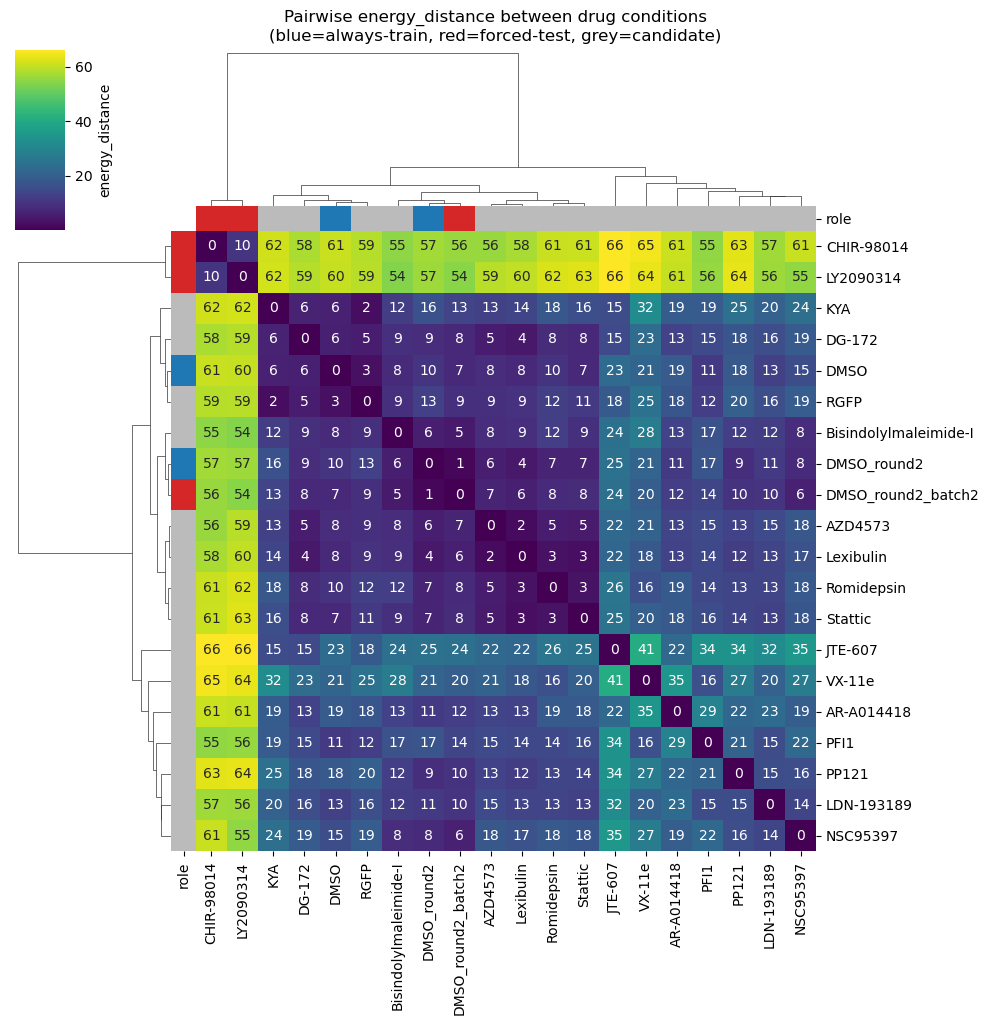

In [61]:
# ---- Heatmap of the full pairwise distance matrix ----------------------
# Ward-clustered heatmap over the universe. Side colours: blue=always-train (DMSO),
# red=forced-test anchors, grey=free candidate.
Dplot = D.loc[universe, universe]

def role_color(d):
    if d in ALWAYS_TRAIN:  return "#1f77b4"
    if d in FORCED_TEST:   return "#d62728"
    return "#bbbbbb"
role_colors = pd.Series({d: role_color(d) for d in universe}, name="role")

g = sns.clustermap(
    Dplot, cmap="viridis", figsize=(10, 10),
    row_colors=role_colors, col_colors=role_colors,
    annot=True, fmt=".0f", annot_kws={"size": 10},
    cbar_kws={"label": METRIC_NAME},
    method="ward",   # Ward minimum-variance (scipy ward = R ward.D2)
)
g.ax_heatmap.set_xlabel(""); g.ax_heatmap.set_ylabel("")
g.fig.suptitle(f"Pairwise {METRIC_NAME} between drug conditions\n"
               "(blue=always-train, red=forced-test, grey=candidate)", y=1.02)
plt.show()

In [62]:
# ---- Brute-force: distance of each test drug to its complement training set
Du = D.loc[universe, universe]
uni_pos = {d: i for i, d in enumerate(universe)}
Dvals = Du.to_numpy()
reduce_fn = {"min": np.min, "mean": np.mean}[DIST_REDUCE]

dist_cols = [f"dist_{i}" for i in range(1, N_TEST + 1)]
name_cols = [f"name_{i}" for i in range(1, N_TEST + 1)]
free_cols = [f"free_{i}" for i in range(1, n_choose + 1)]
n_forced  = len(FORCED_TEST)

records = []
for combo in combinations(free_candidates, n_choose):
    members = list(FORCED_TEST) + list(combo)
    test_idx = np.array([uni_pos[m] for m in members])
    train_mask = np.ones(len(universe), dtype=bool)
    train_mask[test_idx] = False                       # training = universe minus test
    d = np.array([reduce_fn(Dvals[i, train_mask]) for i in test_idx])
    order = np.argsort(d, kind="mergesort")
    d_sorted = d[order]; names_sorted = [members[i] for i in order]
    rec = dict(zip(dist_cols, d_sorted))
    rec.update(dict(zip(name_cols, names_sorted)))
    # distances of the 3 FREE picks only (members after the forced ones), sorted
    free_sorted = np.sort(d[n_forced:])
    rec.update(dict(zip(free_cols, free_sorted)))
    rec["range"] = float(d_sorted[-1] - d_sorted[0])
    records.append(rec)

search = pd.DataFrame.from_records(records)[dist_cols + name_cols + free_cols + ["range"]]
print(f"Built search table: {search.shape[0]} test sets x {len(dist_cols)} sorted distances")
assert search.shape[0] == n_combos
search.head()

Built search table: 455 test sets x 6 sorted distances


,dist_1,dist_2,dist_3,dist_4,dist_5,dist_6,name_1,name_2,name_3,name_4,name_5,name_6,free_1,free_2,free_3,range
0,1.205383,1.953217,5.677341,11.138355,55.274169,55.337204,DMSO_round2_batch2,AZD4573,Bisindolylmaleimide-I,AR-A014418,CHIR-98014,LY2090314,1.953217,5.677341,11.138355,54.131821
1,1.205383,1.953217,4.371002,11.138355,53.878155,54.982361,DMSO_round2_batch2,AZD4573,DG-172,AR-A014418,LY2090314,CHIR-98014,1.953217,4.371002,11.138355,53.776978
2,1.205383,1.953217,11.138355,14.941139,53.878155,54.982361,DMSO_round2_batch2,AZD4573,AR-A014418,JTE-607,LY2090314,CHIR-98014,1.953217,11.138355,14.941139,53.776978
3,1.205383,1.953217,2.224396,11.138355,53.878155,54.982361,DMSO_round2_batch2,AZD4573,KYA,AR-A014418,LY2090314,CHIR-98014,1.953217,2.224396,11.138355,53.776978
4,1.205383,1.953217,11.138355,11.307587,53.878155,54.982361,DMSO_round2_batch2,AZD4573,AR-A014418,LDN-193189,LY2090314,CHIR-98014,1.953217,11.138355,11.307587,53.776978


In [63]:
# ---- The N x 6 numeric matrix (sorted distances) -----------------------
dist_matrix = search[dist_cols].to_numpy()   # (455, 6): easiest -> hardest per row
name_matrix = search[name_cols].to_numpy()
print("dist_matrix shape:", dist_matrix.shape)
print("first 3 rows (distances):\n", np.round(dist_matrix[:3], 3))
print("first 3 rows (names):\n", name_matrix[:3])

dist_matrix shape: (455, 6)
first 3 rows (distances):
 [[ 1.205  1.953  5.677 11.138 55.274 55.337]
 [ 1.205  1.953  4.371 11.138 53.878 54.982]
 [ 1.205  1.953 11.138 14.941 53.878 54.982]]
first 3 rows (names):
 [['DMSO_round2_batch2' 'AZD4573' 'Bisindolylmaleimide-I' 'AR-A014418'
  'CHIR-98014' 'LY2090314']
 ['DMSO_round2_batch2' 'AZD4573' 'DG-172' 'AR-A014418' 'LY2090314'
  'CHIR-98014']
 ['DMSO_round2_batch2' 'AZD4573' 'AR-A014418' 'JTE-607' 'LY2090314'
  'CHIR-98014']]


In [64]:
# ---- Selection: 3 free picks at low / mid-mid / mid --------------------
# Tier targets are fractions of the global achievable distance range.
gmin = float(search["dist_1"].min())     # easiest end (~the DMSO anchor / smallest)
gmax = float(search["dist_6"].max())     # hardest end (the far anchors)
free_targets = gmin + np.array(FREE_TIER_FRACS) * (gmax - gmin)
print("achievable distance range: %.2f -> %.2f" % (gmin, gmax))
for nm, t in zip(TIER_NAMES, free_targets):
    print(f"  target {nm:<8s} = {t:6.2f}")

free_d = search[free_cols].to_numpy()    # 3 free distances, sorted ascending
search["coverage_cost"] = ((free_d - free_targets) ** 2).sum(axis=1)
search_by_cov = search.sort_values("coverage_cost").reset_index(drop=True)

best = search_by_cov.iloc[0]
best_members = [best[c] for c in name_cols]
best_dists   = [float(best[c]) for c in dist_cols]
assert set(FORCED_TEST).issubset(set(best_members)), best_members

def role_of(d):
    if d == FORCED_EASY:  return "easiest"
    if d in FORCED_HARD:  return "hard"
    return "free"
print("\nSelected test set (6 conditions, easy -> hard):")
for n, v in zip(best_members, best_dists):
    print(f"  {role_of(n):<8s} {n:<22s} dist_to_train = {v:7.3f}")
print("coverage_cost = %.3f   range = %.3f" % (best["coverage_cost"], best["range"]))
search_by_cov.head(10)

achievable distance range: 1.21 -> 56.90
  target low      =   1.21
  target mid-mid  =  15.13
  target mid      =  29.05

Selected test set (6 conditions, easy -> hard):
  easiest  DMSO_round2_batch2     dist_to_train =   1.205
  free     Romidepsin             dist_to_train =   2.886
  free     PFI1                   dist_to_train =  11.122
  free     VX-11e                 dist_to_train =  17.950
  hard     LY2090314              dist_to_train =  53.878
  hard     CHIR-98014             dist_to_train =  54.982
coverage_cost = 142.196   range = 53.777


,dist_1,dist_2,dist_3,dist_4,dist_5,dist_6,name_1,name_2,name_3,name_4,name_5,name_6,free_1,free_2,free_3,range,coverage_cost
0,1.205383,2.886402,11.122062,17.950485,53.878155,54.982361,DMSO_round2_batch2,Romidepsin,PFI1,VX-11e,LY2090314,CHIR-98014,2.886402,11.122062,17.950485,53.776978,142.195586
1,1.205383,1.953217,14.941139,16.146660,53.878155,54.982361,DMSO_round2_batch2,AZD4573,JTE-607,VX-11e,LY2090314,CHIR-98014,1.953217,14.941139,16.146660,53.776978,167.214693
2,1.205383,1.953217,14.941139,16.146660,53.878155,54.982361,DMSO_round2_batch2,Lexibulin,JTE-607,VX-11e,LY2090314,CHIR-98014,1.953217,14.941139,16.146660,53.776978,167.214693
3,1.205383,2.224396,14.941139,16.146660,53.878155,54.982361,DMSO_round2_batch2,RGFP,JTE-607,VX-11e,LY2090314,CHIR-98014,2.224396,14.941139,16.146660,53.776978,167.693825
4,1.205383,2.224396,14.941139,16.146660,53.878155,54.982361,DMSO_round2_batch2,KYA,JTE-607,VX-11e,LY2090314,CHIR-98014,2.224396,14.941139,16.146660,53.776978,167.693825
5,1.205383,2.886402,14.941139,16.207385,53.878155,54.982361,DMSO_round2_batch2,Romidepsin,JTE-607,VX-11e,LY2090314,CHIR-98014,2.886402,14.941139,16.207385,53.776978,167.917267
6,1.205383,2.572620,14.941139,16.146660,53.878155,54.982361,DMSO_round2_batch2,Stattic,JTE-607,VX-11e,LY2090314,CHIR-98014,2.572620,14.941139,16.146660,53.776978,168.524776
7,1.205383,4.371002,15.093781,16.146660,53.878155,54.982361,DMSO_round2_batch2,DG-172,JTE-607,VX-11e,LY2090314,CHIR-98014,4.371002,15.093781,16.146660,53.776978,176.642199
8,1.205383,1.953217,11.307587,16.146660,53.878155,54.982361,DMSO_round2_batch2,AZD4573,LDN-193189,VX-11e,LY2090314,CHIR-98014,1.953217,11.307587,16.146660,53.776978,181.790486
9,1.205383,1.953217,11.307587,16.146660,53.878155,54.982361,DMSO_round2_batch2,Lexibulin,LDN-193189,VX-11e,LY2090314,CHIR-98014,1.953217,11.307587,16.146660,53.776978,181.790486


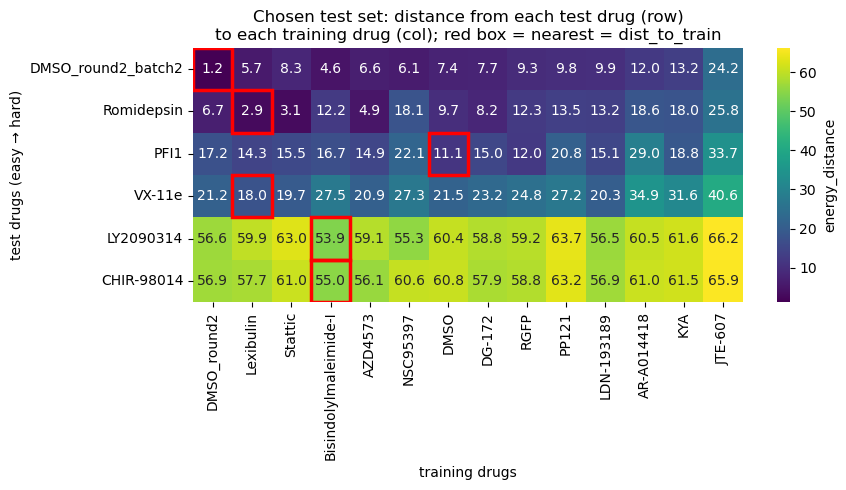

In [71]:
# ---- Heatmap: chosen test set distances to its training drugs ----------
best_test  = best_members
train_cols = [u for u in universe if u not in best_test]                            # training drugs only
col_order  = D.loc[best_test, train_cols].min(axis=0).sort_values().index.tolist()  # near training first
M = D.loc[best_test, col_order]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(M, cmap="viridis", annot=True, fmt=".1f", annot_kws={"size": 10},
            cbar_kws={"label": METRIC_NAME}, ax=ax)
# red box = nearest training drug = dist_to_train
for r, drug in enumerate(best_test):
    c = list(M.columns).index(D.loc[drug, train_cols].idxmin())
    ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor="red", lw=2.5))
ax.set_title("Chosen test set: distance from each test drug (row)\n"
             "to each training drug (col); red box = nearest = dist_to_train")
ax.set_xlabel("training drugs"); ax.set_ylabel("test drugs (easy → hard)")
plt.tight_layout(); plt.show()

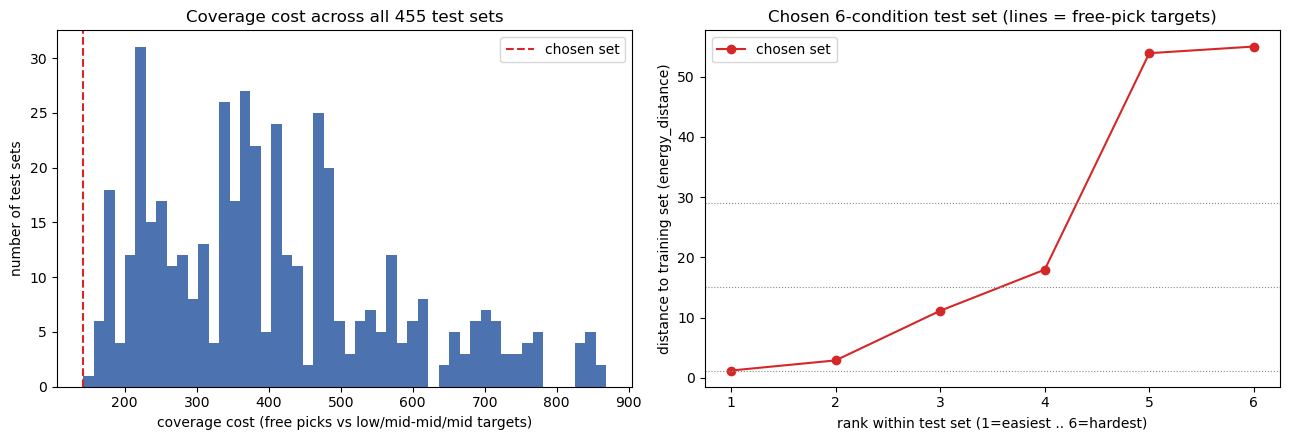

In [66]:
# ---- Visualise coverage ------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(search["coverage_cost"], bins=50, color="#4c72b0")
axes[0].axvline(best["coverage_cost"], color="#d62728", ls="--", label="chosen set")
axes[0].set_xlabel("coverage cost (free picks vs low/mid-mid/mid targets)")
axes[0].set_ylabel("number of test sets")
axes[0].set_title(f"Coverage cost across all {len(search)} test sets")
axes[0].legend()

x = np.arange(1, N_TEST + 1)
axes[1].plot(x, best_dists, "o-", color="#d62728", label="chosen set")
axes[1].set_xticks(x)
axes[1].set_xlabel("rank within test set (1=easiest .. 6=hardest)")
axes[1].set_ylabel(f"distance to training set ({METRIC_NAME})")
for nm, t in zip(TIER_NAMES, free_targets):
    axes[1].axhline(t, color="#888", ls=":", lw=0.8)
axes[1].set_title("Chosen 6-condition test set (lines = free-pick targets)")
axes[1].legend()
plt.tight_layout(); plt.show()

In [67]:
# ---- Save the full search table + chosen split -------------------------
search_by_cov.insert(0, "rank_by_coverage", np.arange(1, len(search_by_cov) + 1))
search_by_cov["metric"] = METRIC_NAME
search_by_cov["dist_reduce"] = DIST_REDUCE
search_by_cov.to_csv(OUT_CSV, index=False)
print(f"Wrote {OUT_CSV}  ({len(search_by_cov)} rows)")

chosen = pd.DataFrame(
    [{"drug": d, "split": "test", "dist_to_train": v, "role": role_of(d)}
     for d, v in zip(best_members, best_dists)]
    + [{"drug": d, "split": "train", "dist_to_train": np.nan, "role": ""}
       for d in universe if d not in best_members]
)
chosen.to_csv(os.path.join(projectDir, "ChosenTrainTestSplit.csv"), index=False)
print("Chosen split ->", os.path.join(projectDir, "ChosenTrainTestSplit.csv"))
chosen[chosen.split == "test"]

Wrote /home/beraslan/Projects/ChemoGeneticScreens/TestSetSearch_easy_3free_hard.csv  (455 rows)
Chosen split -> /home/beraslan/Projects/ChemoGeneticScreens/ChosenTrainTestSplit.csv


,drug,split,dist_to_train,role
0,DMSO_round2_batch2,test,1.205383,easiest
1,Romidepsin,test,2.886402,free
2,PFI1,test,11.122062,free
3,VX-11e,test,17.950485,free
4,LY2090314,test,53.878155,hard
5,CHIR-98014,test,54.982361,hard


## Notes & knobs

- **6 test conditions.** `DMSO_round2_batch2` (easiest, ≈0) + 3 free picks (low / mid-mid / mid) +
  `CHIR-98014`, `LY2090314` (hardest). `DMSO`, `DMSO_round2` stay in training.
- **Selection metric.** `coverage_cost` = squared deviation of the **three free picks** from tier targets
  at 0% / 25% / 50% of the global distance range. The easy/hard anchors are fixed and not scored.
- **Training set = complement.** Distances are measured against `universe \ test`, so a drug's distance
  excludes the other test drugs.
- **Mid-range gap.** Non-anchor drugs cap at ~18 (nothing sits between ~18 and ~54), so the "mid" free pick
  lands near that ceiling; the jump to the hard anchors is inherent to the data.
- **Outputs.** `TestSetSearch_easy_3free_hard.csv` (all 455 sets) and `ChosenTrainTestSplit.csv`.
- **Metric.** Energy distance by default; switch `DIST_FILE`/`METRIC_NAME` to the cosine matrix to repeat.